# justviz + dr2d Demo

GPU-accelerated scatter and bar charts via the dr2d Python binding.

In [1]:
import justviz as jv
import numpy as np

np.random.seed(42)
x1 = np.random.normal(30, 10, 50_000).astype(np.float32)
y1 = np.random.normal(30, 10, 50_000).astype(np.float32)
x2 = np.random.normal(70, 10, 50_000).astype(np.float32)
y2 = np.random.normal(70, 10, 50_000).astype(np.float32)

jv.story(
    layers=[
        {"x": x1, "y": y1, "color": (1.0, 0.3, 0.3), "size": 2.0},
        {"x": x2, "y": y2, "color": (0.3, 0.3, 1.0), "size": 2.0},
    ],
    slides=[
        {"zoom": "fit", "layers": "all", "title": "Full dataset"},
        {"zoom": "fit", "layers": [1], "title": "Cluster A (red)"},
        {"zoom": "fit", "layers": [2], "title": "Cluster B (blue)"},
        {"zoom": "fit", "layers": [1, 2], "title": "Both clusters"},
    ],
)


In [2]:
import justviz as jv
import networkx as nx

# Karate club — interactive with pan/zoom
G = nx.karate_club_graph()
jv.graph(G, color_by="club", node_size=6.0, interactive=True)

# Larger graph
G = nx.barabasi_albert_graph(500, 3)
jv.graph(G, layout="spring", interactive=True)

# Knowledge graph with edge type layers
G = nx.MultiDiGraph()
# ... add edges with 'type' attribute
jv.graph(G, edge_layers="type", interactive=True)
# Press 1/2/3 to toggle edge types


ValueError: Graph must contain at least one node

In [1]:
import numpy as np
from PIL import Image
from IPython.display import display
from justviz import scatter, bar

## 1. Basic Scatter Plot (1K points)

scatter: 1,000 points, 800×600, render 176.9ms


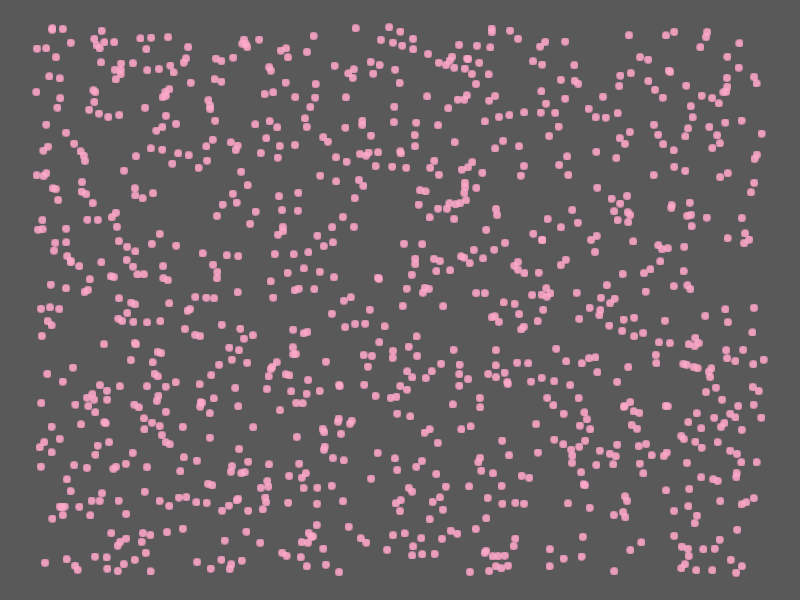

In [3]:
np.random.seed(42)
x = np.random.uniform(0, 100, 1000).astype(np.float32)
y = np.random.uniform(0, 100, 1000).astype(np.float32)

img = scatter(x, y, color=(1.0, 0.4, 0.6), size=4.0, opacity=0.8, width=800, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 2. Basic Bar Chart (8 bars)

bar: 8 bars, 800×600, render 2.7ms


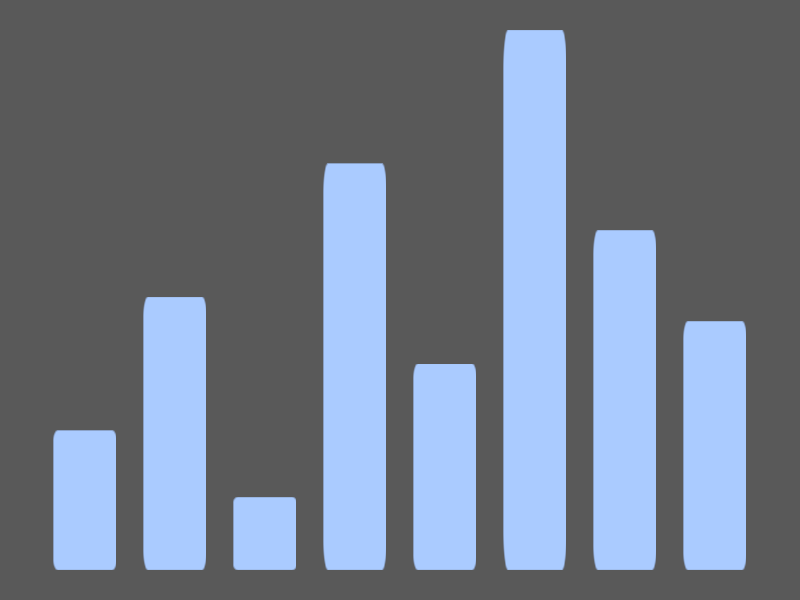

In [4]:
categories = np.arange(8, dtype=np.float32)
values = np.array([23, 45, 12, 67, 34, 89, 56, 41], dtype=np.float32)

img = bar(categories, values, color=(0.4, 0.6, 1.0), bar_width=0.7, width=800, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 3. Multi-Layer Scatter (1M points total)

Total points: 1,000,000
scatter: 1,000,000 points (2 layers), 1024×768, render 218.8ms


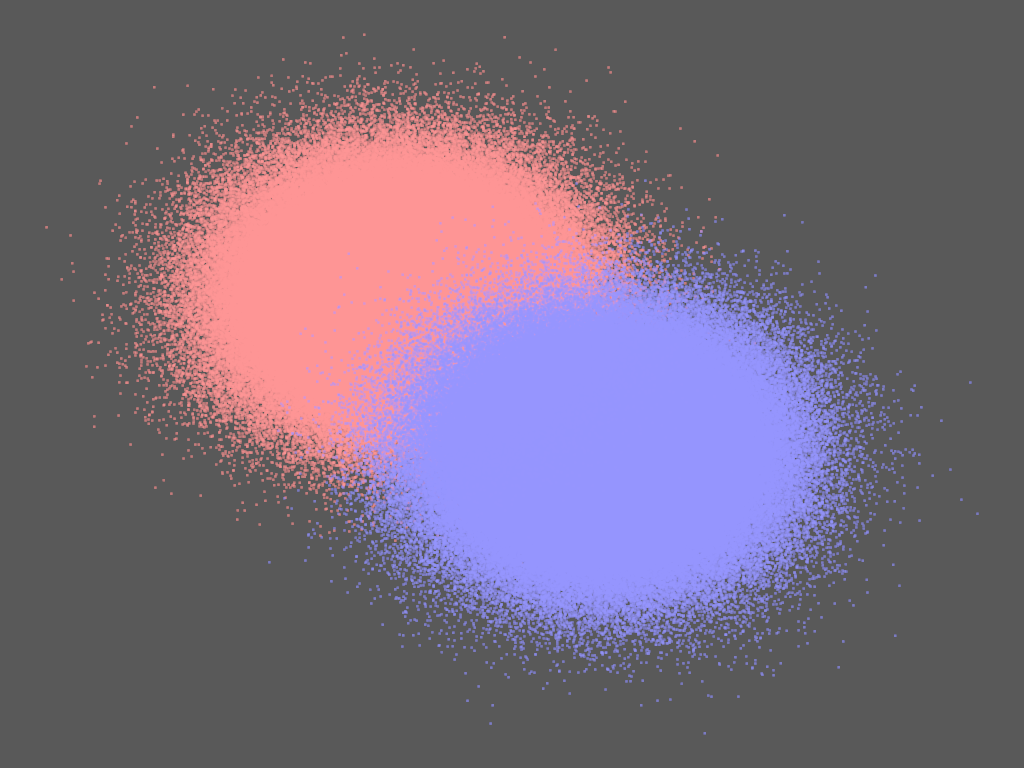

In [5]:
np.random.seed(123)

# Dataset A: 500K points, clustered bottom-left
x1 = np.random.normal(30, 15, 500_000).astype(np.float32)
y1 = np.random.normal(30, 15, 500_000).astype(np.float32)

# Dataset B: 500K points, clustered top-right
x2 = np.random.normal(70, 15, 500_000).astype(np.float32)
y2 = np.random.normal(70, 15, 500_000).astype(np.float32)

print(f"Total points: {len(x1) + len(x2):,}")

img = scatter(
    None, None,
    layers=[
        {"x": x1, "y": y1, "color": (1.0, 0.3, 0.3), "size": 1.5, "opacity": 0.5},
        {"x": x2, "y": y2, "color": (0.3, 0.3, 1.0), "size": 1.5, "opacity": 0.5},
    ],
    width=1024,
    height=768,
)
display(Image.fromarray(img, mode='RGBA'))

## 4. Render Time Comparison — Multiple Runs

First call includes GPU init. Subsequent calls show pure render time.

In [6]:
import time

# 10K points
np.random.seed(0)
x10k = np.random.uniform(0, 100, 10_000).astype(np.float32)
y10k = np.random.uniform(0, 100, 10_000).astype(np.float32)

# 100K points
x100k = np.random.uniform(0, 100, 100_000).astype(np.float32)
y100k = np.random.uniform(0, 100, 100_000).astype(np.float32)

# 1M points
x1m = np.random.uniform(0, 100, 1_000_000).astype(np.float32)
y1m = np.random.uniform(0, 100, 1_000_000).astype(np.float32)

for label, xd, yd in [("10K", x10k, y10k), ("100K", x100k, y100k), ("1M", x1m, y1m)]:
    times = []
    for i in range(3):
        t0 = time.perf_counter()
        img = scatter(xd, yd, color=(0.2, 0.8, 0.4), size=2.0, width=1024, height=768)
        dt = time.perf_counter() - t0
        times.append(dt * 1000)
    print(f"{label:>5s}: run1={times[0]:.0f}ms  run2={times[1]:.0f}ms  run3={times[2]:.0f}ms")

scatter: 10,000 points, 1024×768, render 4.5ms
scatter: 10,000 points, 1024×768, render 4.0ms
scatter: 10,000 points, 1024×768, render 4.2ms
  10K: run1=5ms  run2=5ms  run3=5ms
scatter: 100,000 points, 1024×768, render 26.0ms
scatter: 100,000 points, 1024×768, render 26.3ms
scatter: 100,000 points, 1024×768, render 28.1ms
 100K: run1=31ms  run2=31ms  run3=33ms
scatter: 1,000,000 points, 1024×768, render 234.9ms
scatter: 1,000,000 points, 1024×768, render 240.6ms
scatter: 1,000,000 points, 1024×768, render 229.9ms
   1M: run1=295ms  run2=295ms  run3=284ms


## 5. Load Parquet Data

Loaded 10000 rows: price [10.0, 200.0], volume [100.2, 4999.6]
scatter: 10,000 points, 800×600, render 5.8ms


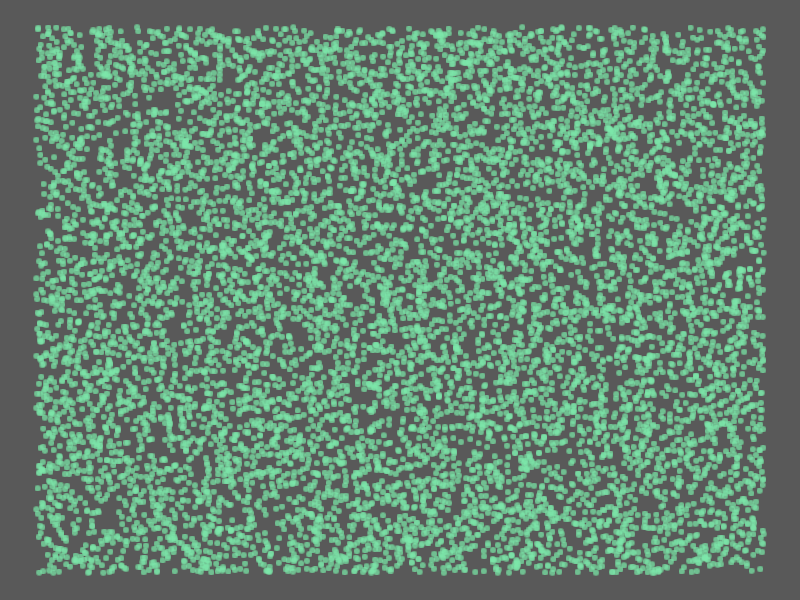

In [7]:
import dr2d
import pyarrow as pa
import pyarrow.parquet as pq

# Generate and save test data
np.random.seed(99)
table = pa.table({
    "price": np.random.uniform(10, 200, 10_000).astype(np.float32),
    "volume": np.random.uniform(100, 5000, 10_000).astype(np.float32),
})
pq.write_table(table, "/tmp/test_data.parquet")

# Load via dr2d
px, py_ = dr2d.load_parquet_columns("/tmp/test_data.parquet", "price", "volume")
print(f"Loaded {len(px)} rows: price [{px.min():.1f}, {px.max():.1f}], volume [{py_.min():.1f}, {py_.max():.1f}]")

img = scatter(px, py_, color=(0.2, 0.8, 0.4), size=3.0, opacity=0.6, width=800, height=600)
display(Image.fromarray(img, mode='RGBA'))

In [7]:
import time
import numpy as np
from justviz import scatter

for n in [2_000_000, 5_000_000, 10_000_000]:
    x = np.random.uniform(0, 100, n).astype(np.float32)
    y = np.random.uniform(0, 100, n).astype(np.float32)
    t0 = time.perf_counter()
    try:
        img = scatter(x, y, color=(0.2, 0.8, 0.4), size=1.0, width=1024, height=768)
        dt = time.perf_counter() - t0
        print(f"{n/1e6:.0f}M: {dt*1000:.0f}ms total, shape={img.shape}")
    except Exception as e:
        dt = time.perf_counter() - t0
        print(f"{n/1e6:.0f}M: FAILED after {dt*1000:.0f}ms — {e}")


scatter: 2,000,000 points, 1024×768, render 483.1ms
2M: 597ms total, shape=(768, 1024, 4)
scatter: 5,000,000 points, 1024×768, render 1096.3ms
5M: 1401ms total, shape=(768, 1024, 4)



thread '<unnamed>' (42956) panicked at /home/skrsan/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/wgpu-24.0.5/src/backend/wgpu_core.rs:1405:18:
wgpu error: Validation Error

Caused by:
  In Device::create_buffer, label = 'sdf_instance_buffer'
    Buffer size 480000000 is greater than the maximum buffer size (268435456)


note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


PanicException: wgpu error: Validation Error

Caused by:
  In Device::create_buffer, label = 'sdf_instance_buffer'
    Buffer size 480000000 is greater than the maximum buffer size (268435456)



## 6. Interactive Window

Opens a GPU window with pan/zoom. Close the window to return to the notebook.

In [ ]:
# Uncomment to open interactive window:
# scatter(x1m, y1m, color=(0.2, 0.8, 0.4), size=1.5, interactive=True)